In [1]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.3 MB/s eta 0:00:00


In [2]:
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import cv2
import math
import random
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
model   = YOLO("/kaggle/input/datasets/tarunpandianm/eric-dataset/eric_v3_best.pt")
val_dir = Path("/kaggle/input/datasets/tarunpandianm/eric-dataset/dataset/val/images")

CLASS_NAMES = {0: "barrier", 1: "cone", 2: "stop_sign"}

bbox_heights = {0: [], 1: [], 2: []}

for img_path in list(val_dir.glob("*"))[:200]:
    results = model.predict(
        source  = str(img_path),
        conf    = 0.3,
        verbose = False
    )
    boxes = results[0].boxes
    if boxes is None:
        continue
    img_h = results[0].orig_shape[0]
    for box in boxes:
        cls_id      = int(box.cls[0])
        _, y1, _, y2 = box.xyxy[0].tolist()
        bbox_h_px   = y2 - y1
        bbox_heights[cls_id].append(bbox_h_px)

print("BBox height stats per class (pixels, img_h=640):")
for cls_id, heights in bbox_heights.items():
    if heights:
        print(f"\n  {CLASS_NAMES[cls_id]}:")
        print(f"    min={min(heights):.1f}  max={max(heights):.1f}")
        print(f"    median={np.median(heights):.1f}")
        print(f"    25th pct={np.percentile(heights,25):.1f}")
        print(f"    75th pct={np.percentile(heights,75):.1f}")
        print(f"    n={len(heights)}")

BBox height stats per class (pixels, img_h=640):

  barrier:
    min=11.8  max=1306.1
    median=84.7
    25th pct=49.3
    75th pct=145.0
    n=106

  cone:
    min=9.7  max=235.8
    median=31.1
    25th pct=21.2
    75th pct=52.8
    n=878

  stop_sign:
    min=26.2  max=75.3
    median=46.2
    25th pct=30.5
    75th pct=62.4
    n=5


In [4]:
img = cv2.imread('/kaggle/input/datasets/tarunpandianm/eric-dataset/dataset/val/images/IMG_3968_JPG_jpg.rf.c86b7205ccabebbddef77c9dc9f4e9d6.jpg')
img.shape

(640, 640, 3)

## Distance Estimation

Distance is estimated using a **monocular pinhole-camera model** based on the detected object's bounding-box height. The relationship used is:

**D = (H × f) / h**

where `H` is the assumed real-world object height, `f` is the camera focal length in pixels, and `h` is the object's bounding-box height in pixels.

The focal length is estimated from the image width and assumed horizontal FOV:

**f = (W / 2) / tan(FOV / 2)**

This method was chosen because the assignment requires a geometry-based estimate and the pipeline uses a single camera. It avoids requiring stereo cameras, depth sensors, or an additional depth-estimation model, while remaining lightweight enough for eventual edge deployment.

The resulting value represents an **approximate camera-to-object distance**, with accuracy depending on the assumed object dimensions, camera FOV, and bounding-box localization.

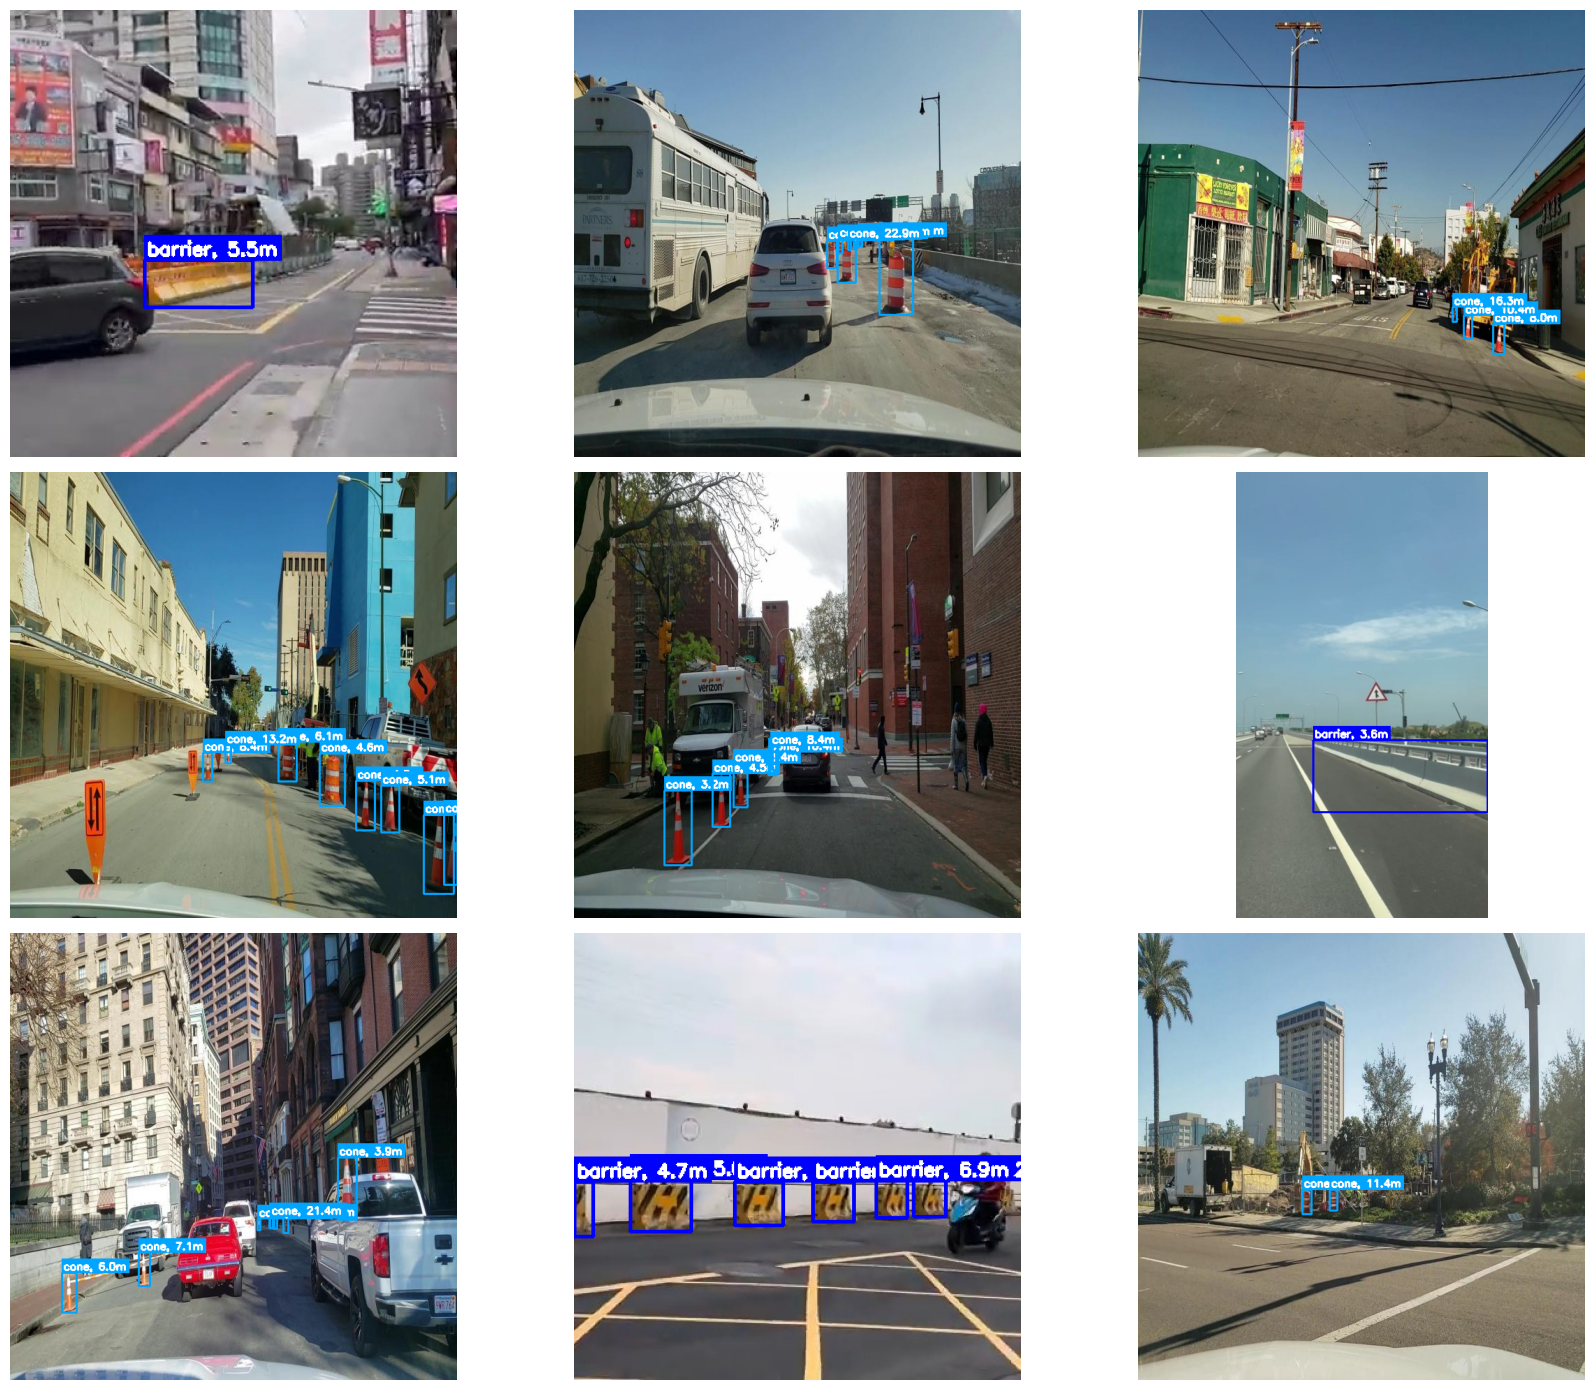

Saved: detection_distance.png


In [5]:

IMG_W    = 640
FOV_DEG  = 70
FOCAL_PX = (IMG_W / 2) / math.tan(math.radians(FOV_DEG / 2))

# real object heights (m) — international standards 
REAL_HEIGHTS = {
    "barrier"   : 0.81,
    "cone"      : 0.75,
    "stop_sign" : 0.75,
}

MIN_DIST = 0.5   # closer than 0.5m = bbox fills frame, noise
MAX_DIST = 50.0  # farther than 50m = bbox too tiny, noise

CLASS_NAMES = {0: "barrier", 1: "cone", 2: "stop_sign"}
COLORS      = {0: (0,0,255), 1: (0,165,255), 2: (0,255,0)}


def estimate_distance(bbox_h_px, img_h, class_name):
    """
    Pinhole camera model:
    D = (H_real * f) / h_px
    
    H_real -> known real object height (m)
    f      -> focal length in pixels
    h_px   -> detected bbox height in pixels
    """
    if bbox_h_px < 1:
        return None
    bbox_h_normalized = bbox_h_px * (640 / img_h)
    dist = (REAL_HEIGHTS[class_name] * FOCAL_PX) / bbox_h_normalized
    dist = max(MIN_DIST, min(MAX_DIST, dist))
    return round(dist, 1)

val_dir = Path("/kaggle/input/datasets/tarunpandianm/eric-dataset/dataset/val/images")
samples = random.sample(list(val_dir.glob("*")), min(9, len(list(val_dir.glob("*")))))

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes      = axes.flatten()

for ax, img_path in zip(axes, samples):
    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model.predict(
        source  = str(img_path),
        conf    = 0.3,
        verbose = False
    )

    img_h = results[0].orig_shape[0]
    img_w = results[0].orig_shape[1]

    annotated = img_rgb.copy()
    boxes     = results[0].boxes

    if boxes is not None:
        for box in boxes:
            cls_id   = int(box.cls[0])
            cls_name = CLASS_NAMES.get(cls_id, "unknown")
            x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
            bbox_h_px    = y2 - y1
            dist         = estimate_distance(bbox_h_px, img_h, cls_name)
            color        = COLORS.get(cls_id, (255,255,255))

            cv2.rectangle(annotated, (x1,y1), (x2,y2), color, 2)
            label = f"{cls_name}, {dist}m" if dist else cls_name

            (tw, th), _ = cv2.getTextSize(
                label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
            cv2.rectangle(
                annotated, (x1, y1-th-8), (x1+tw+4, y1), color, -1)
            cv2.putText(
                annotated, label, (x1+2, y1-4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)

    ax.imshow(annotated)
    ax.set_aspect('equal')
    ax.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/detection_distance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: detection_distance.png")

In [7]:
# run on all val images and summarize
from collections import defaultdict
import numpy as np

distance_log = defaultdict(list)

for img_path in list(val_dir.glob("*")):
    results = model.predict(source=str(img_path), conf=0.3, verbose=False)
    boxes   = results[0].boxes
    img_h   = results[0].orig_shape[0]

    if boxes is None:
        continue

    for box in boxes:
        cls_id   = int(box.cls[0])
        cls_name = CLASS_NAMES[cls_id]
        _, y1, _, y2 = box.xyxy[0].tolist()
        bbox_h_px = y2 - y1
        dist = estimate_distance(bbox_h_px, img_h, cls_name)
        if dist:
            distance_log[cls_name].append(dist)

print("Distance estimation summary across val set:")
print(f"{'Class':<12} {'Count':>6} {'Min':>8} {'Max':>8} {'Mean':>8} {'Median':>8}")
print()
for cls, dists in distance_log.items():
    print(f"{cls:<12} {len(dists):>6} {min(dists):>8.1f}m {max(dists):>8.1f}m "
          f"{np.mean(dists):>8.1f}m {np.median(dists):>8.1f}m")

Distance estimation summary across val set:
Class         Count      Min      Max     Mean   Median

barrier         300      0.6m     26.7m      4.1m      2.8m
cone           2770      1.4m     43.0m     11.8m     10.3m
stop_sign        26      3.2m     16.6m      8.9m      9.1m
